# Domain-SupportSpecialist — Entire Fine-Tuning Project, One-Shot Visual Summary


In [ ]:
# mount Drive and locate the project
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/Domain-SupportSpecialist'
print('Project root:', PROJECT)

!pip install -q pandas matplotlib ipywidgets

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Domain-SupportSpecialist


## 1. Project overview

In [ ]:
from IPython.display import display, HTML, Markdown

display(Markdown("""
**Domain:** Customer Support Assistant — refunds, order tracking, cancellations, replacements, delivery, payment issues.

**Business problem:** Support tickets repeat the same ~15 request types. A generic AI assistant deflects to "contact customer service" instead of actually answering, because it has no company-specific knowledge. Fine-tuning fixes that.

**Pipeline:** Base model → Stage 1 (non-instruction FT) → Stage 2 (instruction FT / SFT) → Stage 3 (DPO preference alignment) → final assistant.

**Base model:** `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit`, QLoRA throughout.
"""))


**Domain:** Customer Support Assistant — refunds, order tracking, cancellations, replacements, delivery, payment issues.

**Business problem:** Support tickets repeat the same ~15 request types. A generic AI assistant deflects to "contact customer service" instead of actually answering, because it has no company-specific knowledge. Fine-tuning fixes that.

**Pipeline:** Base model → Stage 1 (non-instruction FT) → Stage 2 (instruction FT / SFT) → Stage 3 (DPO preference alignment) → final assistant.

**Base model:** `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit`, QLoRA throughout.


## 2. Dataset sizes

In [ ]:
import pandas as pd

def count_jsonl(path):
    with open(path, encoding='utf-8') as f:
        return sum(1 for _ in f)

def count_paragraphs(path):
    with open(path, encoding='utf-8') as f:
        return len([p for p in f.read().split('\n\n') if p.strip()])

dataset_summary = pd.DataFrame([
    {"File": "non_instruction_data.txt", "Rows": count_paragraphs(f"{PROJECT}/data/non_instruction_data.txt"), "Shape": "plain paragraphs", "Used by": "Stage 1"},
    {"File": "instruction_dataset.jsonl", "Rows": count_jsonl(f"{PROJECT}/data/instruction_dataset.jsonl"), "Shape": "{instruction, response}", "Used by": "Stage 2"},
    {"File": "preference_dataset.jsonl", "Rows": count_jsonl(f"{PROJECT}/data/preference_dataset.jsonl"), "Shape": "{prompt, chosen, rejected}", "Used by": "Stage 3"},
])
dataset_summary

,File,Rows,Shape,Used by
0,non_instruction_data.txt,184,plain paragraphs,Stage 1
1,instruction_dataset.jsonl,200,"{instruction, response}",Stage 2
2,preference_dataset.jsonl,100,"{prompt, chosen, rejected}",Stage 3


## 3. LoRA / QLoRA configuration

In [ ]:
config_summary = pd.DataFrame([
    {"Setting": "LoRA rank (r)", "Value": "16"},
    {"Setting": "LoRA alpha", "Value": "16"},
    {"Setting": "LoRA dropout", "Value": "0"},
    {"Setting": "Target modules", "Value": "q/k/v/o/gate/up/down projections"},
    {"Setting": "Base weight precision", "Value": "4-bit (QLoRA)"},
    {"Setting": "Trainable parameters", "Value": "18,464,768 / 1,562,179,072 (1.18%)"},
    {"Setting": "Learning rate (Stage 1-2)", "Value": "2e-4"},
    {"Setting": "Learning rate (Stage 3, DPO)", "Value": "5e-6"},
    {"Setting": "Effective batch size", "Value": "8 (2 x 4 grad-accum)"},
    {"Setting": "DPO beta", "Value": "0.1"},
])
config_summary

,Setting,Value
0,LoRA rank (r),16
1,LoRA alpha,16
2,LoRA dropout,0
3,Target modules,q/k/v/o/gate/up/down projections
4,Base weight precision,4-bit (QLoRA)
5,Trainable parameters,"18,464,768 / 1,562,179,072 (1.18%)"
6,Learning rate (Stage 1-2),2e-4
7,"Learning rate (Stage 3, DPO)",5e-6
8,Effective batch size,8 (2 x 4 grad-accum)
9,DPO beta,0.1


## 4. Training curves — all 3 stages, real logged values

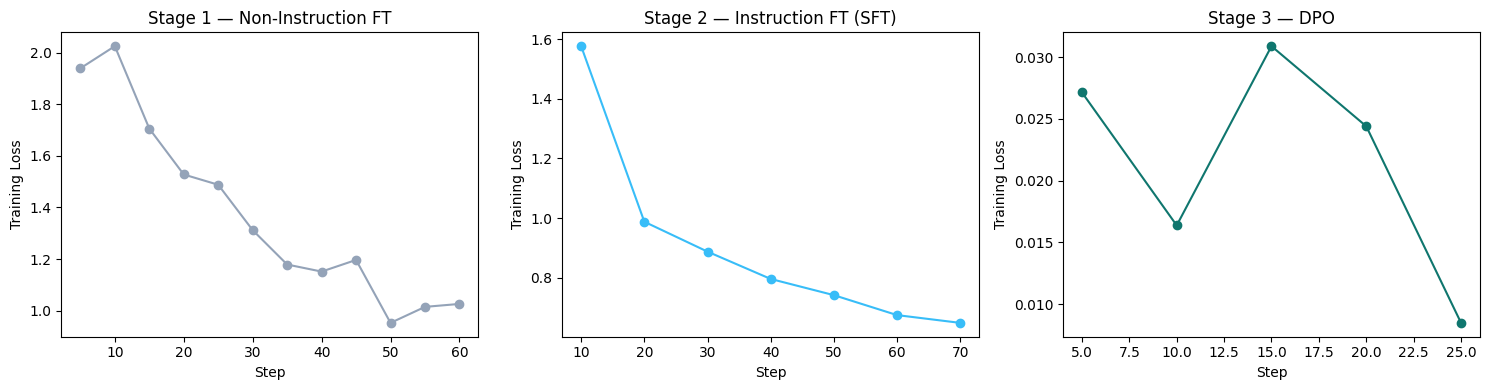

Stage 1 (warm-up on raw text): loss trends down with some noise, 1.94 -> ~1.0
Stage 2 (SFT, structured task): clean steady drop, 1.58 -> 0.65
Stage 3 (DPO): loss near-zero almost immediately; rewards/accuracies = 1.0 on
every logged step means chosen answers were ranked above rejected ones 100% of
the time in-batch -- fast convergence, expected for a small clean preference set.


In [ ]:
import matplotlib.pyplot as plt

stage1 = pd.DataFrame({
    "Step": [5,10,15,20,25,30,35,40,45,50,55,60],
    "Training Loss": [1.939523,2.025378,1.705911,1.527913,1.488091,1.312090,1.178858,1.151445,1.196575,0.952569,1.014675,1.026075],
})
stage2 = pd.DataFrame({
    "Step": [10,20,30,40,50,60,70],
    "Training Loss": [1.576857,0.987686,0.887399,0.795725,0.741381,0.674428,0.648318],
})
stage3 = pd.DataFrame({
    "Step": [5,10,15,20,25],
    "Training Loss": [0.027146,0.016372,0.030889,0.024401,0.008479],
    "rewards/chosen": [7.976250,7.120978,8.782237,7.620154,8.730283],
    "rewards/rejected": [-0.345975,-0.476447,-0.559537,-0.616968,-0.555615],
    "rewards/accuracies": [1.0,1.0,1.0,1.0,1.0],
    "rewards/margins": [8.322226,7.597425,9.341775,8.237123,9.285896],
})

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(stage1["Step"], stage1["Training Loss"], marker='o', color='#94a3b8')
axes[0].set_title("Stage 1 — Non-Instruction FT")
axes[1].plot(stage2["Step"], stage2["Training Loss"], marker='o', color='#38bdf8')
axes[1].set_title("Stage 2 — Instruction FT (SFT)")
axes[2].plot(stage3["Step"], stage3["Training Loss"], marker='o', color='#0f766e')
axes[2].set_title("Stage 3 — DPO")
for ax in axes:
    ax.set_xlabel("Step"); ax.set_ylabel("Training Loss")
plt.tight_layout()
plt.show()

print("Stage 1 (warm-up on raw text): loss trends down with some noise, 1.94 -> ~1.0")
print("Stage 2 (SFT, structured task): clean steady drop, 1.58 -> 0.65")
print("Stage 3 (DPO): loss near-zero almost immediately; rewards/accuracies = 1.0 on")
print("every logged step means chosen answers were ranked above rejected ones 100% of")
print("the time in-batch -- fast convergence, expected for a small clean preference set.")

In [ ]:
display(stage3)

,Step,Training Loss,rewards/chosen,rewards/rejected,rewards/accuracies,rewards/margins
0,5,0.027146,7.976250,-0.345975,1.0,8.322226
1,10,0.016372,7.120978,-0.476447,1.0,7.597425
2,15,0.030889,8.782237,-0.559537,1.0,9.341775
3,20,0.024401,7.620154,-0.616968,1.0,8.237123
4,25,0.008479,8.730283,-0.555615,1.0,9.285896


## 5. Interactive Base vs SFT vs DPO comparison dashboard
Reads the already-verified `reports/*.md` files and renders them as real,
sortable tables plus an interactive question picker.

In [ ]:
QUESTIONS = [
    "How can I cancel my order after it has been placed?",
    "My package says delivered but I never received it, what do I do?",
    "How long does a refund take to appear on my card?",
    "Can I change the delivery address after checkout?",
    "The item I received is damaged, what are my options?",
    "How do I track my order status?",
    "I was charged twice for one order, how do I fix this?",
    "Can I get a replacement instead of a refund?",
    "What happens if I miss the delivery attempt?",
    "How do I apply a discount code after placing an order?",
]

def parse_markdown_table(path):
    with open(path, encoding='utf-8') as f:
        text = f.read()

    # header is the first '|'-line that isn't the '|---|---|' divider
    header_line = next(l for l in text.splitlines() if l.startswith('|') and '---' not in l)
    header = [c.strip() for c in header_line.strip('|').split('|')]

    # anchor-based row extraction, not a naive per-line parser -- several
    # answers in these reports span multiple physical lines (numbered
    # steps), and a plain "keep lines starting with |" filter silently
    # drops those rows entirely instead of just mis-splitting them
    anchors = []
    for q in QUESTIONS:
        marker = f"| {q} |"
        idx = text.find(marker)
        if idx != -1:
            anchors.append((idx, q))
    anchors.sort()

    rows = []
    for i, (idx, q) in enumerate(anchors):
        end = anchors[i + 1][0] if i + 1 < len(anchors) else len(text)
        block = text[idx:end].strip()
        parts = [p.strip() for p in block.split('|')]
        parts = [p for p in parts if p != ''] if parts and parts[0] == '' else parts
        if len(parts) >= len(header):
            rows.append(parts[:len(header)])
    return pd.DataFrame(rows, columns=header)

pd.set_option('display.max_colwidth', 80)
base_df = parse_markdown_table(f'{PROJECT}/reports/base_model_evaluation.md')
sft_df = parse_markdown_table(f'{PROJECT}/reports/sft_model_comparison.md')
final_df = parse_markdown_table(f'{PROJECT}/reports/final_evaluation.md')

print("Base model evaluation:")
display(base_df)

Base model evaluation:


,Question,Base Model Answer,Problem
0,How can I cancel my order after it has been placed?,"To cancel an order that you've already placed, follow these steps:\n\n1. **L...","Trails off mid-sentence (""wait for confirmation that the order..."") and neve..."
1,"My package says delivered but I never received it, what do I do?",If you've been notified that your package has been delivered but you haven't...,"Gives genuinely complete, actionable troubleshooting steps, but frames the w..."
2,How long does a refund take to appear on my card?,The time it takes for a refund to appear on your credit card depends on seve...,Lists generic banking factors instead of ever giving an actual number or tim...
3,Can I change the delivery address after checkout?,"Yes, you can change your delivery address after checking out. Most online sh...","Reasonable step outline, but hedges like a random third-party retailer (""som..."
4,"The item I received is damaged, what are my options?","If you have received an item that is damaged or not as expected, there are s...","Uses marketplace language (""contact the seller,"" ""some sellers offer"") as if..."
5,How do I track my order status?,"To track your order status, follow these general steps:\n\n1. **Check the We...",Reads like generic e-commerce advice scattered across unrelated channels (we...
6,"I was charged twice for one order, how do I fix this?","If you have been charged twice for the same order, there could be several re...",Tells the customer to contact THEIR OWN bank's customer support rather than ...
7,Can I get a replacement instead of a refund?,"Yes, you can often get a replacement item in addition to a refund if the iss...","Opens with ""Yes,"" but the phrasing (""a replacement item in addition to a ref..."
8,What happens if I miss the delivery attempt?,"If you miss the delivery attempt, it means that your package was not deliver...","Explains general shipping-carrier behavior reasonably well, but never states..."
9,How do I apply a discount code after placing an order?,"To apply a discount code after placing an order, follow these steps:\n\n1. *...",Mostly describes applying a discount DURING checkout rather than AFTER placi...


In [ ]:
print("Base vs SFT comparison:")
display(sft_df)

sft_tally = sft_df['Which is Better?'].value_counts().reindex(['Base','SFT','Tie']).fillna(0).astype(int)
display(sft_tally.rename_axis('Model').reset_index(name='Questions Won (out of 10)'))

Base vs SFT comparison:


,Question,Base,SFT,Which is Better?,Reason
0,How can I cancel my order after it has been placed?,"To cancel an order that you've already placed, follow these steps:\n\n1. **L...",I understand your need to cancel your order and we're here to assist you wit...,SFT,"SFT names our actual portal (support.example.com), the Order History section..."
1,"My package says delivered but I never received it, what do I do?",If you've been notified that your package has been delivered but you haven't...,I understand your confusion and frustration in not receiving the package you...,Base,"Base gives 5 complete, genuinely actionable troubleshooting steps (check not..."
2,How long does a refund take to appear on my card?,The time it takes for a refund to appear on your credit card depends on seve...,We appreciate your patience as we work towards resolving this issue for you....,SFT,"SFT at least attempts a direct answer (""a few business days""); Base explains..."
3,Can I change the delivery address after checkout?,"Yes, you can change your delivery address after checking out. Most online sh...",I can see that you're interested in changing your delivery address after com...,SFT,"SFT gives concrete, company-specific steps (Order History section, a real or..."
4,"The item I received is damaged, what are my options?","If you have received an item that is damaged or not as expected, there are s...",I'm sorry to hear that you have encountered an issue with the item you recei...,SFT,"SFT delivers 4 complete, concrete options (replacement, refund, in-store pic..."
5,How do I track my order status?,"To track your order status, follow these general steps:\n\n1. **Check the We...",I understand your curiosity about how to track the status of your order. To ...,Base,"Base at least lists real methods to check order status (website, app, contac..."
6,"I was charged twice for one order, how do I fix this?","If you have been charged twice for the same order, there could be several re...",We apologize for the inconvenience caused to you. To address your concern ab...,SFT,Base's serious flaw here is telling the customer to contact THEIR OWN bank's...
7,Can I get a replacement instead of a refund?,"Yes, you can often get a replacement item in addition to a refund if the iss...",I'm on it! I completely understand your desire for a replacement rather than...,Base,"Base is the only one that actually answers the yes/no question (""Yes, you ca..."
8,What happens if I miss the delivery attempt?,"If you miss the delivery attempt, it means that your package was not deliver...","If you miss one of our delivery attempts, we understand how frustrating that...",SFT,"SFT commits to concrete actions in our own voice (rescheduling, reaching out..."
9,How do I apply a discount code after placing an order?,"To apply a discount code after placing an order, follow these steps:\n\n1. *...","Sure! To use the discount code after placing your order, follow these steps:...",SFT,SFT directly addresses applying a code AFTER placing an order with concrete ...


,Model,Questions Won (out of 10)
0,Base,3
1,SFT,7
2,Tie,0


Base vs SFT vs DPO — final evaluation:


,Question,Base,SFT,DPO,Best Answer,Reason
0,How can I cancel my order after it has been placed?,"To cancel an order that you've already placed, follow these steps:\n\n1. **L...",I understand your need to cancel your order and we're here to assist you wit...,"I've got all the information you need to cancel your order! Rest assured, we...",DPO,"Adds an explicit ""Confirm Your Decision"" step on top of the same account/por..."
1,"My package says delivered but I never received it, what do I do?",If you've been notified that your package has been delivered but you haven't...,I understand your confusion and frustration in not receiving the package you...,I appreciate your concern in this situation. It can be frustrating when you ...,DPO,"DPO points to our actual portal's ""Tracking"" section and gives a real phone ..."
2,How long does a refund take to appear on my card?,The time it takes for a refund to appear on your credit card depends on seve...,We appreciate your patience as we work towards resolving this issue for you....,I understand your eagerness to know the estimated time it takes for your ref...,DPO,"DPO gives the same vague ""a few business days"" as SFT, but adds a real phone..."
3,Can I change the delivery address after checkout?,"Yes, you can change your delivery address after checking out. Most online sh...",I can see that you're interested in changing your delivery address after com...,I'm on it! I completely understand that you would like to make changes to yo...,DPO,"DPO's ""Edit Delivery Address"" option label is the most precisely scoped of t..."
4,"The item I received is damaged, what are my options?","If you have received an item that is damaged or not as expected, there are s...",I'm sorry to hear that you have encountered an issue with the item you recei...,I understand that you have encountered an issue with the item you received a...,SFT,"SFT delivers 4 complete, concrete options (replacement, refund, in-store pic..."
5,How do I track my order status?,"To track your order status, follow these general steps:\n\n1. **Check the We...",I understand your curiosity about how to track the status of your order. To ...,I'm on it! To check the status of your order and stay updated with any chang...,DPO,"DPO names our real website and a specific ""Order Tracking"" section, then poi..."
6,"I was charged twice for one order, how do I fix this?","If you have been charged twice for the same order, there could be several re...",We apologize for the inconvenience caused to you. To address your concern ab...,We apologize for the inconvenience caused you. To resolve the issue of being...,DPO,Base's serious flaw is telling the customer to contact THEIR OWN bank's supp...
7,Can I get a replacement instead of a refund?,"Yes, you can often get a replacement item in addition to a refund if the iss...",I'm on it! I completely understand your desire for a replacement rather than...,I'm on it! I completely understand that you're seeking assistance in obtaini...,Base,"Base is the only one that actually answers the yes/no question up front (""Ye..."
8,What happens if I miss the delivery attempt?,"If you miss the delivery attempt, it means that your package was not deliver...","If you miss one of our delivery attempts, we understand how frustrating that...","If you miss a delivery attempt, we understand that it can be frustrating. Ou...",SFT,"SFT commits to concrete actions in our own voice (rescheduling, updated cont..."
9,How do I apply a discount code after placing an order?,"To apply a discount code after placing an order, follow these steps:\n\n1. *...","Sure! To use the discount code after placing your order, follow these steps:...","I'm on it! To use the discount code for your order, please follow these step...",SFT,SFT's flow is clean and consistent (Order History -> Discounts/Promotions ->...


,Model,Questions Won (out of 10),Win Rate
0,Base,1,10%
1,SFT,3,30%
2,DPO,6,60%


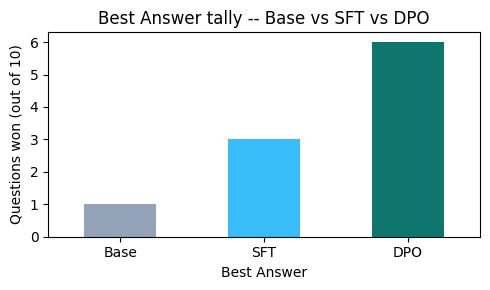

In [ ]:
print("Base vs SFT vs DPO — final evaluation:")
display(final_df)

tally = final_df['Best Answer'].value_counts().reindex(['Base','SFT','DPO']).fillna(0).astype(int)
tally_df = tally.rename_axis('Model').reset_index(name='Questions Won (out of 10)')
tally_df['Win Rate'] = (tally_df['Questions Won (out of 10)'] / 10 * 100).map(lambda x: f"{x:.0f}%")
display(tally_df)

ax = tally.plot(kind='bar', color=['#94a3b8','#38bdf8','#0f766e'], figsize=(5,3))
ax.set_ylabel('Questions won (out of 10)')
ax.set_title('Best Answer tally -- Base vs SFT vs DPO')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets

question_dropdown = widgets.Dropdown(
    options=final_df['Question'].tolist(),
    description='Question:',
    layout=widgets.Layout(width='90%'),
    style={'description_width': 'initial'},
)
output_box = widgets.Output()

def render_row(change=None):
    output_box.clear_output()
    row = final_df[final_df['Question'] == question_dropdown.value].iloc[0]
    with output_box:
        display(HTML(f"""
        <div style="font-family:sans-serif;max-width:900px">
          <p><b>Best Answer:</b> {row['Best Answer']} &mdash; <i>{row['Reason']}</i></p>
          <table style="width:100%;border-collapse:collapse">
            <tr><th style="text-align:left;border-bottom:1px solid #ccc;padding:4px">Base</th></tr>
            <tr><td style="padding:4px;border-bottom:1px solid #eee">{row['Base']}</td></tr>
            <tr><th style="text-align:left;border-bottom:1px solid #ccc;padding:4px">SFT</th></tr>
            <tr><td style="padding:4px;border-bottom:1px solid #eee">{row['SFT']}</td></tr>
            <tr><th style="text-align:left;border-bottom:1px solid #ccc;padding:4px">DPO</th></tr>
            <tr><td style="padding:4px">{row['DPO']}</td></tr>
          </table>
        </div>
        """))

question_dropdown.observe(render_row, names='value')
display(question_dropdown, output_box)
render_row()

Dropdown(description='Question:', layout=Layout(width='90%'), options=('How can I cancel my order after it has…

Output()

## Summary
This notebook is a bonus artifact, not a required deliverable — everything
it shows comes from files already in `data/`, `reports/`, and this
README's training logs. Nothing here needs to be saved or resubmitted; it
exists purely to make demoing the project faster than scrolling raw
markdown files.